### Calculates time series of volume-integrated numerical and physical mixing of temp and salt for a subset of ROMS model output

In [1]:
#Packages 
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

/global/u2/d/dylan617/miconda3/envs/xroms/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def open_roms(path):
    '''
Opens a single netcdf files with xroms. The chunks 
argument is if you get dask errors when computing gradients. 
If one appears, uncomment, then add "chunks=chunks" to 
xroms.open_netcdf. Do the same thing to open_mfnetcdf if the 
error appears!
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
    #     for k, v in chunk.items():
    #         chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_netcdf(path,)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms.
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

# 20 layer w/ ice
path = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/roms_avg_beaufort_dvd_myroms_ice_32x8_u3c4_20vert_0002_42602118_0001.nc'
ds20, grid20 = open_roms(path)
# 30 layer w/ ice
path = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_30vert_scratch/roms_avg_beaufort_dvd_myroms_ice_32x8_u3c4_30vert_42527571_0001.nc'
ds30, grid30 = open_roms(path)

In [ ]:
# See invariants_pdfs.ipynb for a plan view of the control volume
xislice = slice(300,500)
etaslice = slice(80,170)

def calculate_mixing(ds,grid,etaslice,xislice):
    #Physical mixing. Need to interpolate to the s-rho points from the s-w points
    Akr_rho = grid.interp(ds.AKr, 'Z')
    mphys = (Akr_rho*ds.dV).isel(eta_rho = etaslice, xi_rho = xislice).sum(['eta_rho', 'xi_rho', 's_rho'])
    mphys.attrs = ''

    mnums = (ds.dye_03*ds.dV).isel(eta_rho = etaslice, xi_rho = xislice).sum(['eta_rho', 'xi_rho', 's_rho'])
    mnums.attrs = ''

    #Temperature
    Akrt_rho = grid.interp(ds.AKrt, 'Z')
    mphyt = (Akrt_rho*ds.dV).isel(eta_rho = etaslice, xi_rho = xislice).sum(['eta_rho', 'xi_rho', 's_rho'])
    mphyt.attrs = ''

    mnumt = (ds.dye_06*ds.dV).isel(eta_rho = etaslice, xi_rho = xislice).sum(['eta_rho', 'xi_rho', 's_rho'])
    mnumt.attrs = ''

    # Create dataset to hold mixing quantities
    mix_arr = xr.Dataset({'mphys':mphys, 'mphyt':mphyt, 'mnums':mnums, 'mnumt':mnumt})
    return mix_arr

mix_arr_20 = calculate_mixing(ds20,grid20,etaslice,xislice)
mix_arr_30 = calculate_mixing(ds30,grid30,etaslice,xislice)

# mix_arr_20.to_netcdf('mix_arr_20.nc')
# print('mix_arr_20 complete')
# mix_arr_30.to_netcdf('mix_arr_30.nc')
# print('mix_arr_30 complete')

In [ ]:
mix_arr_20.mphys.to_netcdf('mphys.nc')
print('mphys complete')
mix_arr_20.mphyt.to_netcdf('mphyt.nc')
print('mphyt complete')
mix_arr_20.mnums.to_netcdf('mnums.nc')
print('mnums complete')
mix_arr_20.mnumt.to_netcdf('mnumt.nc')
print('mnumt complete')

mphys complete
mphyt complete
mphys complete
mphyt complete


In [8]:
mix_arr_30.mphys.to_netcdf('mphys_30.nc')
print('mphys complete')
mix_arr_30.mphyt.to_netcdf('mphyt_30.nc')
print('mphyt complete')
mix_arr_30.mnums.to_netcdf('mnums_30.nc')
print('mnums complete')
mix_arr_30.mnumt.to_netcdf('mnumt_30.nc')
print('mnumt complete')

mphys complete
mphyt complete
mphys complete
mphyt complete


### Plot the time series comparing 20 and 30 layer runs

In [18]:
mphys_20 = xr.open_dataset('mphys.nc').mphys
mphyt_20 = xr.open_dataset('mphyt.nc').mphyt
mnums_20 = xr.open_dataset('mnums.nc').mnums
mnumt_20 = xr.open_dataset('mnumt.nc').mnumt

mphys_30 = xr.open_dataset('mphys_30.nc').mphys
mphyt_30 = xr.open_dataset('mphyt_30.nc').mphyt
mnums_30 = xr.open_dataset('mnums_30.nc').mnums
mnumt_30 = xr.open_dataset('mnumt_30.nc').mnumt
# mphys_20

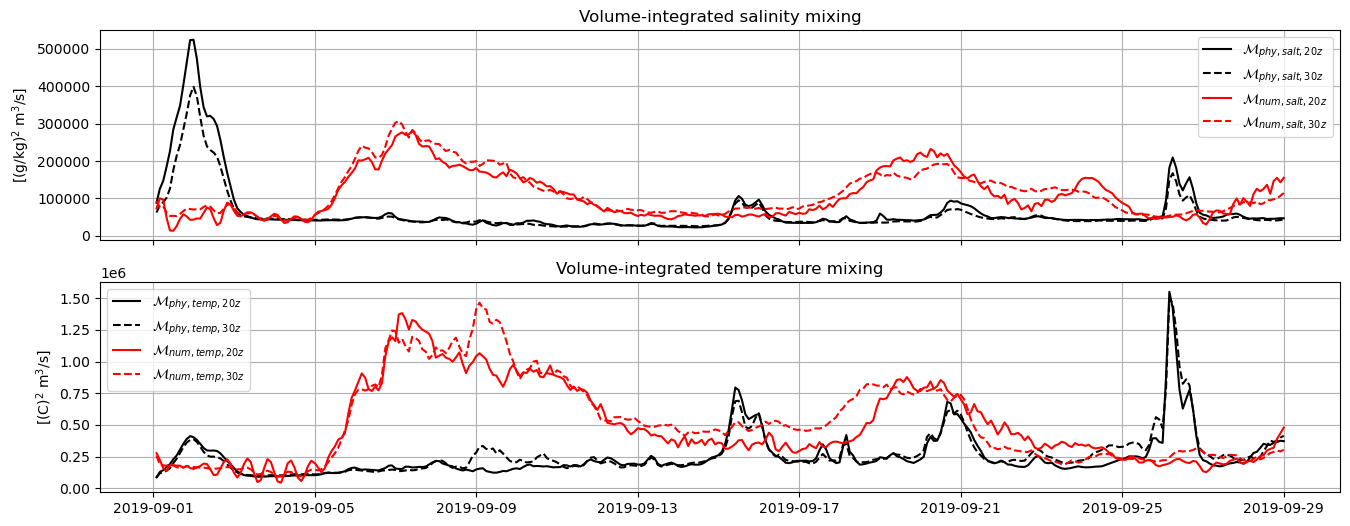

In [23]:
fig, ax = plt.subplots(2, figsize=(16,6))

# Plot physical and numerical mixing of salinity 
ax[0].plot(mphys_20.ocean_time, mphys_20, color='k', label=r'$\mathcal{M}_{phy,salt,20z}$')
ax[0].plot(mphys_30.ocean_time, mphys_30, color='k', ls = '--', label=r'$\mathcal{M}_{phy,salt,30z}$')
ax[0].plot(mnums_20.ocean_time, mnums_20, color='r', label=r'$\mathcal{M}_{num,salt,20z}$')
ax[0].plot(mnums_30.ocean_time, mnums_30, color='r', ls = '--', label=r'$\mathcal{M}_{num,salt,30z}$')

ax[0].set_ylabel('[(g/kg)$^2$ m$^3$/s]')
ax[0].set_title(r'Volume-integrated salinity mixing')

# Plot physical and numerical mixing of temperature
ax[1].plot(mphyt_20.ocean_time, mphyt_20, color='k', label=r'$\mathcal{M}_{phy,temp,20z}$')
ax[1].plot(mphyt_30.ocean_time, mphyt_30, color='k', ls = '--', label=r'$\mathcal{M}_{phy,temp,30z}$')
ax[1].plot(mnumt_20.ocean_time, mnumt_20, color='r', label=r'$\mathcal{M}_{num,temp,20z}$')
ax[1].plot(mnumt_30.ocean_time, mnumt_30, color='r', ls = '--', label=r'$\mathcal{M}_{num,temp,30z}$')

# Plot physical and numerical mixing of temperature 
ax[1].set_ylabel('[(C)$^2$ m$^3$/s]')
ax[1].set_title(r'Volume-integrated temperature mixing')

# Add legends
ax[0].legend()
ax[0].set_xticklabels('')
ax[1].legend()
ax[0].grid()
ax[1].grid()

# fig.subplots_adjust(hspace=0.4)

# ax[0].semilogy()
# ax[1].semilogy()

In [30]:
print(mphys_20.sum()/(mnums_20.sum()))
print(mphys_30.sum()/(mnums_30.sum()))

print(mphyt_20.sum()/(mnumt_20.sum()))
print(mphyt_30.sum()/(mnumt_30.sum()))


<xarray.DataArray ()> Size: 8B
array(0.59629474)
<xarray.DataArray ()> Size: 8B
array(0.48709311)
<xarray.DataArray ()> Size: 8B
array(0.50892353)
<xarray.DataArray ()> Size: 8B
array(0.51188528)
